# 04 — Rotation-consistent query-gated UVD

## Research question

Can an equivariance objective reduce orientation sensitivity without changing the evaluation protocol?

**Method.** RGB, masks, U, V, and D are spatially co-rotated and predictions are aligned before the consistency loss is measured.

**Controlled hypothesis.** Consistency regularization should improve robustness while retaining query-conditioned geometry.

All experiments use the same Pascal-Part-116 splits, frozen DINOv2/OpenCLIP
encoders, preprocessing, optimizer family, evaluation metrics, and
validation-only checkpoint-selection rule. Test metrics are reported only after
the checkpoint has been selected.

> **Rotation convention:** RGB, parent mask, part mask, U, V, and D are co-rotated. U and V retain the original object-relative coordinate values; they are not recomputed in the rotated image frame.


## Notebook roadmap

1. Resolve repository paths and choose fresh or resumed training.
2. Define the controlled configuration, preprocessing, dataset, model, and loss.
3. Verify the prepared splits and visualize one model-ready sample.
4. Train with validation-IoU checkpoint selection.
5. Compare seen and unseen performance against the object-mask baseline.
6. Inspect per-query behavior, geometry gates, qualitative predictions, and saved artifacts.


In [1]:
from pathlib import Path
import json
import os
import sys

from IPython.display import Image, display

PROJECT_ROOT = next(
    (path for path in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
     if (path / "datasets").is_dir() and (path / "final_model").is_dir()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Run from the repository or final_training_notebooks directory")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

RUN_ID = os.environ.get("FINAL_TRAINING_RUN_ID", "manual")
TRAIN_MODEL = False
FRESH_TRAINING = True
RESULT_ROOT = PROJECT_ROOT / "training_results_corrected"
POINT_ROOT = RESULT_ROOT
print("Project:", PROJECT_ROOT)
print("Run ID:", RUN_ID)


Project: /home/utn/ojug99ek/Computer_Vision_Object-Relative-Spatial-Encoding-for-Open-Vocabulary-Part-Segmentation
Run ID: manual


## 1. Reproducible setup, data, and preprocessing

This section fixes seeds, resolves repository-relative paths, defines the matched
training protocol, prepares RGB and binary masks, and constructs object-relative
U, V, and boundary-distance D channels. Encoder weights are downloaded from their
official sources once and then reused from the standard local caches.

In [2]:
import json
import os
import platform
import random
import shutil
import sys
import time
from contextlib import nullcontext
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Any

import matplotlib

matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import open_clip
import pandas as pd
from scipy.ndimage import distance_transform_edt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision.transforms import InterpolationMode
from torchvision.transforms import functional as TF
from tqdm.auto import tqdm


from datasets import PascalPart116Dataset


DINO_REPOSITORY = "facebookresearch/dinov2"
DINO_MODEL = "dinov2_vits14"
CLIP_MODEL = "ViT-B-32-quickgelu"
CLIP_PRETRAINED = "openai"


EXPERIMENTS = {
    "baseline_object_mask": {
        "title": "Object-mask baseline",
        "question": "How strong is text-conditioned part segmentation without explicit geometry?",
        "geometry": "none",
        "regularizer": "none",
    },
    "fixed_uvd": {
        "title": "Fixed object-relative UVD",
        "question": "Does explicit object-relative position and boundary distance improve the baseline?",
        "geometry": "fixed U, V, and D",
        "regularizer": "none",
    },
    "query_gated_uvd": {
        "title": "Query-gated object-relative UVD",
        "question": "Should each part query control how strongly U, V, and D are used?",
        "geometry": "query-conditioned U, V, and D",
        "regularizer": "none",
    },
    "rotation_consistent": {
        "title": "Rotation-consistent query-gated UVD",
        "question": "Does an equivariance loss reduce orientation sensitivity?",
        "geometry": "query-conditioned U, V, and D",
        "regularizer": "90-degree rotation consistency",
    },
    "geometry_dropout": {
        "title": "Query-gated UVD with geometry dropout",
        "question": "Does joint geometry-branch dropout reduce over-reliance on object masks?",
        "geometry": "query-conditioned U, V, and D",
        "regularizer": "joint UVD dropout",
    },
}


@dataclass(frozen=True)
class TrainingConfig:
    experiment: str
    seed: int = 42
    image_size: int = 224
    max_epochs: int = 30
    min_epochs: int = 8
    early_stopping_patience: int = 5
    early_stopping_min_delta: float = 0.001
    learning_rate: float = 1e-3
    weight_decay: float = 1e-4
    batch_size: int = 8
    gradient_accumulation_steps: int = 2
    evaluation_batch_size: int = 16
    visual_dim: int = 128
    text_dim: int = 32
    gate_hidden_dim: int = 64
    mask_threshold: float = 0.5
    rotation_loss_weight: float = 0.20
    geometry_dropout_probability: float = 0.30
    selection_split: str = "validation_seen"

    def __post_init__(self) -> None:
        if self.experiment not in EXPERIMENTS:
            raise ValueError(f"Unknown experiment: {self.experiment}")
        if self.min_epochs > self.max_epochs:
            raise ValueError("min_epochs cannot exceed max_epochs")


def run_id() -> str:
    return os.environ.get("FINAL_TRAINING_RUN_ID", "manual")


def points_root() -> Path:
    path = PROJECT_ROOT / "training_results_corrected"
    path.mkdir(parents=True, exist_ok=True)
    return path


def results_root() -> Path:
    path = PROJECT_ROOT / "training_results_corrected"
    path.mkdir(parents=True, exist_ok=True)
    return path


def seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def get_rng_state() -> dict[str, Any]:
    state: dict[str, Any] = {
        "python": random.getstate(),
        "numpy": np.random.get_state(),
        "torch": torch.get_rng_state(),
    }
    if torch.cuda.is_available():
        state["cuda"] = torch.cuda.get_rng_state_all()
    return state


def set_rng_state(state: dict[str, Any]) -> None:
    random.setstate(state["python"])
    np.random.set_state(state["numpy"])
    torch.set_rng_state(state["torch"].cpu())
    if torch.cuda.is_available() and "cuda" in state:
        torch.cuda.set_rng_state_all([value.cpu() for value in state["cuda"]])


IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406], dtype=torch.float32).view(3, 1, 1)
IMAGENET_STD = torch.tensor([0.229, 0.224, 0.225], dtype=torch.float32).view(3, 1, 1)


def resize_info(height: int, width: int, target: int) -> dict[str, int | float]:
    scale = min(target / height, target / width)
    new_h, new_w = max(1, round(height * scale)), max(1, round(width * scale))
    pad_h, pad_w = target - new_h, target - new_w
    top, left = pad_h // 2, pad_w // 2
    return {
        "new_h": new_h,
        "new_w": new_w,
        "top": top,
        "bottom": pad_h - top,
        "left": left,
        "right": pad_w - left,
        "scale": scale,
    }


def preprocess_image(image: torch.Tensor, target: int) -> tuple[torch.Tensor, torch.Tensor]:
    image = image.float() / 255.0
    _, height, width = image.shape
    info = resize_info(height, width, target)
    resized = TF.resize(
        image,
        [int(info["new_h"]), int(info["new_w"])],
        interpolation=InterpolationMode.BILINEAR,
        antialias=True,
    )
    padding = (int(info["left"]), int(info["right"]), int(info["top"]), int(info["bottom"]))
    display = F.pad(resized, padding).clamp(0, 1)
    normalized = F.pad((resized - IMAGENET_MEAN) / IMAGENET_STD, padding)
    return display, normalized


def preprocess_mask(mask: torch.Tensor, height: int, width: int, target: int) -> torch.Tensor:
    info = resize_info(height, width, target)
    value = mask.float().unsqueeze(0) if mask.ndim == 2 else mask.float()
    resized = TF.resize(
        value,
        [int(info["new_h"]), int(info["new_w"])],
        interpolation=InterpolationMode.NEAREST,
    )
    if value.sum() > 0 and resized.sum() == 0:
        resized = F.interpolate(
            value.unsqueeze(0),
            size=(int(info["new_h"]), int(info["new_w"])),
            mode="area",
        ).squeeze(0).gt(0).float()
    padding = (int(info["left"]), int(info["right"]), int(info["top"]), int(info["bottom"]))
    return F.pad(resized, padding).gt(0.5)


def relative_uvd(object_mask: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    mask = object_mask.squeeze(0).bool()
    height, width = mask.shape
    u = torch.zeros((height, width), dtype=torch.float32)
    v = torch.zeros_like(u)
    ys, xs = torch.where(mask)
    if xs.numel() == 0:
        return u.unsqueeze(0), v.unsqueeze(0), u.unsqueeze(0)
    x_min, x_max, y_min, y_max = xs.min(), xs.max(), ys.min(), ys.max()
    u[ys, xs] = (xs.float() - x_min.float()) / max(int(x_max - x_min), 1)
    v[ys, xs] = (ys.float() - y_min.float()) / max(int(y_max - y_min), 1)
    mask_numpy = mask.numpy()
    padded = np.pad(mask_numpy.astype(np.uint8), 1, mode="constant")
    distance = distance_transform_edt(padded)[1:-1, 1:-1].astype(np.float32)
    maximum = float(distance[mask_numpy].max())
    if maximum > 0:
        distance /= maximum
    d = torch.from_numpy(distance) * mask.float()
    return u.unsqueeze(0), v.unsqueeze(0), d.unsqueeze(0)


class GeometryDataset(Dataset):
    def __init__(self, split: str, image_size: int = 224) -> None:
        self.base = PascalPart116Dataset(split=split)
        self.image_size = image_size

    def __len__(self) -> int:
        return len(self.base)

    def __getitem__(self, index: int) -> dict[str, Any]:
        sample = self.base[index]
        height, width = sample["image"].shape[-2:]
        display, image = preprocess_image(sample["image"], self.image_size)
        object_mask = preprocess_mask(sample["object_mask"], height, width, self.image_size)
        part_mask = preprocess_mask(sample["part_mask"], height, width, self.image_size)
        if part_mask.any() and not (part_mask & object_mask).any():
            object_mask |= part_mask
        part_mask &= object_mask
        u, v, d = relative_uvd(object_mask)
        return {
            "index": index,
            "sample_id": sample["sample_id"],
            "image_id": sample["image_id"],
            "query": sample["query"],
            "object_name": sample["object_name"],
            "part_name": sample["part_name"],
            "display_image": display,
            "image": image,
            "object_mask": object_mask.float(),
            "part_mask": part_mask.float(),
            "u": u,
            "v": v,
            "d": d,
        }


class TextCache:
    def __init__(self, model: nn.Module, tokenizer: Any, device: torch.device, use_amp: bool) -> None:
        self.model = model
        self.tokenizer = tokenizer
        self.device = device
        self.use_amp = use_amp
        self.cache: dict[str, torch.Tensor] = {}

    @torch.no_grad()
    def __call__(self, queries: list[str] | tuple[str, ...]) -> torch.Tensor:
        missing = sorted(set(queries) - self.cache.keys())
        if missing:
            prompts = [f"a photo of the {query} of an object" for query in missing]
            tokens = self.tokenizer(prompts).to(self.device)
            context = torch.autocast("cuda", dtype=torch.float16) if self.use_amp else nullcontext()
            with context:
                embeddings = F.normalize(self.model.encode_text(tokens).float(), dim=-1)
            self.cache.update({query: value.cpu() for query, value in zip(missing, embeddings)})
        return torch.stack([self.cache[query] for query in queries]).to(self.device, non_blocking=True)


## 2. Architecture and objective

The segmentation head receives frozen visual features, the frozen text-query
embedding, the parent-object mask, and the geometry channels enabled by this
experiment. BCE and Dice losses optimize foreground localization; IoU, Dice, and
out-of-parent leakage are reported separately.

In [3]:
class PartSegmenter(nn.Module):
    def __init__(self, dino: nn.Module, config: TrainingConfig) -> None:
        super().__init__()
        self.dino = dino
        self.experiment = config.experiment
        self.dropout_probability = config.geometry_dropout_probability
        for parameter in self.dino.parameters():
            parameter.requires_grad = False
        self.visual_projection = nn.Conv2d(384, config.visual_dim, 1)
        self.text_projection = nn.Sequential(
            nn.Linear(512, 64), nn.GELU(), nn.Linear(64, config.text_dim)
        )
        if self.experiment in {
            "query_gated_uvd",
            "rotation_consistent",
            "geometry_dropout",
        }:
            self.geometry_gate = nn.Sequential(
                nn.Linear(512, config.gate_hidden_dim),
                nn.GELU(),
                nn.Linear(config.gate_hidden_dim, 3),
            )
            nn.init.zeros_(self.geometry_gate[-1].weight)
            nn.init.zeros_(self.geometry_gate[-1].bias)
        else:
            self.geometry_gate = None
        fusion_dim = config.visual_dim + config.text_dim + 1 + 3
        self.decoder = nn.Sequential(
            nn.Conv2d(fusion_dim, 128, 3, padding=1),
            nn.GroupNorm(8, 128),
            nn.GELU(),
            nn.Conv2d(128, 64, 3, padding=1),
            nn.GroupNorm(8, 64),
            nn.GELU(),
            nn.Conv2d(64, 32, 3, padding=1),
            nn.GELU(),
            nn.Conv2d(32, 1, 1),
        )

    def train(self, mode: bool = True) -> "PartSegmenter":
        super().train(mode)
        self.dino.eval()
        return self

    @torch.no_grad()
    def visual_features(self, images: torch.Tensor) -> torch.Tensor:
        tokens = self.dino.forward_features(images)["x_norm_patchtokens"]
        batch, count, channels = tokens.shape
        grid = int(count**0.5)
        if grid * grid != count:
            raise RuntimeError(f"DINO patch count is not square: {count}")
        return tokens.transpose(1, 2).reshape(batch, channels, grid, grid)

    def forward(
        self,
        images: torch.Tensor,
        text_embeddings: torch.Tensor,
        object_mask: torch.Tensor,
        u: torch.Tensor,
        v: torch.Tensor,
        d: torch.Tensor,
    ) -> tuple[torch.Tensor, dict[str, torch.Tensor]]:
        visual = self.visual_projection(self.visual_features(images))
        text = self.text_projection(text_embeddings)
        text_map = text[:, :, None, None].expand(-1, -1, *visual.shape[-2:])
        mask_low = F.interpolate(object_mask, visual.shape[-2:], mode="nearest")
        geometry = torch.cat(
            [
                F.interpolate(value, visual.shape[-2:], mode="bilinear", align_corners=False)
                for value in (u, v, d)
            ],
            dim=1,
        ) * mask_low
        batch_size = text_embeddings.shape[0]

        if self.experiment == "baseline_object_mask":
            learned_gates = torch.zeros(
                batch_size, 3, device=text_embeddings.device, dtype=text_embeddings.dtype
            )
            effective_gates = learned_gates
        elif self.experiment == "fixed_uvd":
            learned_gates = torch.ones(
                batch_size, 3, device=text_embeddings.device, dtype=text_embeddings.dtype
            )
            effective_gates = learned_gates
        else:
            assert self.geometry_gate is not None
            learned_gates = torch.sigmoid(self.geometry_gate(text_embeddings))
            effective_gates = learned_gates
        geometry = geometry * effective_gates[:, :, None, None]
        dropped = torch.zeros(len(images), dtype=torch.bool, device=images.device)
        if self.training and self.experiment == "geometry_dropout":
            dropped = torch.rand(len(images), device=images.device) < self.dropout_probability
            geometry = geometry * (~dropped)[:, None, None, None]
        low_logits = self.decoder(torch.cat([visual, text_map, mask_low, geometry], dim=1))
        logits = F.interpolate(low_logits, images.shape[-2:], mode="bilinear", align_corners=False)
        return logits, {
            "learned_gates": learned_gates,
            "effective_gates": effective_gates,
            "geometry_dropped": dropped,
        }


def segmentation_loss(logits: torch.Tensor, target: torch.Tensor) -> dict[str, torch.Tensor]:
    target = target.float()
    positive = target.sum().clamp_min(1)
    negative = (target.numel() - target.sum()).clamp_min(1)
    positive_weight = (negative / positive).clamp(1, 20).detach()
    bce = F.binary_cross_entropy_with_logits(logits, target, pos_weight=positive_weight)
    probability = torch.sigmoid(logits)
    intersection = (probability * target).flatten(1).sum(1)
    dice_loss = 1 - ((2 * intersection + 1) / (probability.flatten(1).sum(1) + target.flatten(1).sum(1) + 1)).mean()
    return {"total": bce + dice_loss, "bce": bce, "dice_loss": dice_loss}


def sample_metrics(
    logits: torch.Tensor,
    target: torch.Tensor,
    object_mask: torch.Tensor,
    threshold: float,
) -> dict[str, torch.Tensor]:
    prediction = torch.sigmoid(logits) >= threshold
    truth = target > 0.5
    parent = object_mask > 0.5
    intersection = (prediction & truth).flatten(1).sum(1).float()
    union = (prediction | truth).flatten(1).sum(1).float()
    predicted = prediction.flatten(1).sum(1).float()
    truth_count = truth.flatten(1).sum(1).float()
    leakage = (prediction & ~parent).flatten(1).sum(1).float() / predicted.clamp_min(1)
    return {
        "iou": intersection / union.clamp_min(1),
        "dice": 2 * intersection / (predicted + truth_count).clamp_min(1),
        "leakage": leakage,
        "part_ratio": truth_count / parent.flatten(1).sum(1).float().clamp_min(1),
    }


## 3. Training, evaluation, and checkpoint policy

All models use the same optimizer, effective batch size, early-stopping rule, and
data splits. `best.pt` is selected only by validation-seen IoU. `last.pt` supports
resume, while test-seen and test-unseen metrics are evaluated after selection.

In [4]:
class TrainingRuntime:
    def __init__(self, config: TrainingConfig) -> None:
        self.config = config
        seed_everything(config.seed)
        if not torch.cuda.is_available():
            raise RuntimeError("Full training requires a CUDA-capable local GPU")
        self.device = torch.device("cuda:0")
        self.use_amp = True
        torch.backends.cudnn.benchmark = True
        torch.set_float32_matmul_precision("high")
        self.checkpoint_dir = points_root() / config.experiment
        self.result_dir = results_root() / config.experiment
        self.checkpoint_dir.mkdir(parents=True, exist_ok=True)
        self.result_dir.mkdir(parents=True, exist_ok=True)
        workers = min(12, max(1, (os.cpu_count() or 1) - 2))
        self.datasets = {
            split: GeometryDataset(split, config.image_size)
            for split in ("train_seen", "validation_seen", "test_seen", "test_unseen")
        }
        self.train_generator = torch.Generator().manual_seed(config.seed)
        common = {
            "num_workers": workers,
            "pin_memory": True,
            "persistent_workers": workers > 0,
        }
        if workers:
            common["prefetch_factor"] = 2
        self.loaders = {
            "train_seen": DataLoader(
                self.datasets["train_seen"],
                batch_size=config.batch_size,
                shuffle=True,
                generator=self.train_generator,
                drop_last=False,
                **common,
            ),
            **{
                split: DataLoader(
                    self.datasets[split],
                    batch_size=config.evaluation_batch_size,
                    shuffle=False,
                    **common,
                )
                for split in ("validation_seen", "test_seen", "test_unseen")
            },
        }
        self.dino = self._load_dino()
        clip_model, _, _ = open_clip.create_model_and_transforms(
            CLIP_MODEL, pretrained=CLIP_PRETRAINED
        )
        clip_model = clip_model.to(self.device).eval()
        for parameter in clip_model.parameters():
            parameter.requires_grad = False
        self.text = TextCache(
            clip_model,
            open_clip.get_tokenizer(CLIP_MODEL),
            self.device,
            self.use_amp,
        )
        queries = sorted(
            {
                record["query"]
                for split in ("train_seen", "validation_seen", "test_seen", "test_unseen")
                for record in self.datasets[split].base.records
            }
        )
        self.text(queries)

    def _load_dino(self) -> nn.Module:
        stale = [name for name in sys.modules if name == "dinov2" or name.startswith("dinov2.")]
        for name in sorted(stale, reverse=True):
            del sys.modules[name]
        model = torch.hub.load(
            DINO_REPOSITORY,
            DINO_MODEL,
            pretrained=True,
            trust_repo=True,
            force_reload=False,
        )
        model = model.to(self.device).eval()
        for parameter in model.parameters():
            parameter.requires_grad = False
        return model

    def build_model(self) -> PartSegmenter:
        seed_everything(self.config.seed)
        return PartSegmenter(self.dino, self.config).to(self.device)

    @staticmethod
    def trainable_state(model: nn.Module) -> dict[str, torch.Tensor]:
        return {
            key: value.detach().cpu()
            for key, value in model.state_dict().items()
            if not key.startswith("dino.")
        }

    @staticmethod
    def load_trainable_state(model: nn.Module, state: dict[str, torch.Tensor]) -> None:
        result = model.load_state_dict(state, strict=False)
        missing = [key for key in result.missing_keys if not key.startswith("dino.")]
        if missing or result.unexpected_keys:
            raise RuntimeError(f"Checkpoint mismatch: missing={missing}, unexpected={result.unexpected_keys}")

    def move(self, batch: dict[str, Any]) -> dict[str, torch.Tensor]:
        return {
            key: batch[key].to(self.device, non_blocking=True)
            for key in ("image", "object_mask", "part_mask", "u", "v", "d")
        }

    def epoch(
        self,
        model: PartSegmenter,
        loader: DataLoader,
        optimizer: torch.optim.Optimizer | None = None,
        scaler: torch.amp.GradScaler | None = None,
    ) -> dict[str, float]:
        training = optimizer is not None
        model.train(training)
        totals = {key: torch.zeros((), device=self.device, dtype=torch.float64) for key in ("loss", "iou", "dice", "leakage")}
        count = 0
        iterator = tqdm(loader, desc="train" if training else "validation", leave=False)
        if training:
            optimizer.zero_grad(set_to_none=True)
        for batch_index, batch in enumerate(iterator):
            values = self.move(batch)
            text = self.text(batch["query"])
            with torch.set_grad_enabled(training), torch.autocast("cuda", dtype=torch.float16):
                logits, _ = model(values["image"], text, values["object_mask"], values["u"], values["v"], values["d"])
                losses = segmentation_loss(logits, values["part_mask"])
                total_loss = losses["total"]
                if training and self.config.experiment == "rotation_consistent":
                    turns = int(torch.randint(1, 4, (1,), device=self.device).item())
                    rotated = {
                        key: torch.rot90(values[key], turns, (-2, -1))
                        for key in ("image", "object_mask", "part_mask")
                    }
                    rotated_geometry = [
                        relative_uvd(mask.detach().cpu())
                        for mask in rotated["object_mask"]
                    ]
                    for index, key in enumerate(("u", "v", "d")):
                        rotated[key] = torch.stack(
                            [geometry[index] for geometry in rotated_geometry], dim=0
                        ).to(self.device, non_blocking=True)
                    rotated_logits, _ = model(
                        rotated["image"], text, rotated["object_mask"], rotated["u"], rotated["v"], rotated["d"]
                    )
                    rotated_loss = segmentation_loss(rotated_logits, rotated["part_mask"])["total"]
                    aligned_probability = torch.rot90(torch.sigmoid(rotated_logits), -turns, (-2, -1))
                    consistency = F.mse_loss(aligned_probability, torch.sigmoid(logits))
                    total_loss = 0.5 * (total_loss + rotated_loss) + self.config.rotation_loss_weight * consistency
            if training:
                assert scaler is not None
                scaler.scale(total_loss / self.config.gradient_accumulation_steps).backward()
                accumulation_boundary = (batch_index + 1) % self.config.gradient_accumulation_steps == 0
                final_batch = batch_index + 1 == len(loader)
                if accumulation_boundary or final_batch:
                    scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_((p for p in model.parameters() if p.requires_grad), 1.0)
                    scaler.step(optimizer)
                    scaler.update()
                    optimizer.zero_grad(set_to_none=True)
            metrics = sample_metrics(logits, values["part_mask"], values["object_mask"], self.config.mask_threshold)
            batch_size = len(values["image"])
            totals["loss"] += total_loss.detach().double() * batch_size
            for key in ("iou", "dice", "leakage"):
                totals[key] += metrics[key].sum().double()
            count += batch_size
        return {key: float(value.item() / count) for key, value in totals.items()}

    def metadata(self) -> dict[str, Any]:
        return {
            **asdict(self.config),
            **EXPERIMENTS[self.config.experiment],
            "run_id": run_id(),
            "device": str(self.device),
            "gpu": torch.cuda.get_device_name(0),
            "gpu_count": torch.cuda.device_count(),
            "amp": "float16",
            "cudnn_benchmark": torch.backends.cudnn.benchmark,
            "python": platform.python_version(),
            "torch": torch.__version__,
            "weight_source": "online with automatic local caching",
            "dino_repository": DINO_REPOSITORY,
            "dino_model": DINO_MODEL,
            "clip_model": CLIP_MODEL,
            "clip_pretrained": CLIP_PRETRAINED,
            "split_sizes": {name: len(dataset) for name, dataset in self.datasets.items()},
            "checkpoint_selection": "maximum validation_seen IoU; test sets are not used for selection",
        }

    def save_checkpoint(self, checkpoint: dict[str, Any], name: str) -> Path:
        target = self.checkpoint_dir / name
        temporary = target.with_suffix(target.suffix + ".tmp")
        torch.save(checkpoint, temporary)
        temporary.replace(target)
        return target

    def train(self) -> tuple[PartSegmenter, pd.DataFrame, dict[str, Any]]:
        completion_path = self.result_dir / "completion.json"
        fresh_run = FRESH_TRAINING
        if not fresh_run and completion_path.is_file() and (self.checkpoint_dir / "best.pt").is_file():
            print(f"{self.config.experiment} is already complete for run {run_id()}; reusing artifacts.")
            model, checkpoint = self.load_best()
            return model, pd.read_csv(self.result_dir / "history.csv"), checkpoint
        config = self.metadata()
        (self.result_dir / "config.json").write_text(json.dumps(config, indent=2) + "\n")
        model = self.build_model()
        optimizer = torch.optim.AdamW(
            (parameter for parameter in model.parameters() if parameter.requires_grad),
            lr=self.config.learning_rate,
            weight_decay=self.config.weight_decay,
        )
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode="max", factor=0.5, patience=2
        )
        scaler = torch.amp.GradScaler("cuda")
        history: list[dict[str, Any]] = []
        best_value = -float("inf")
        best_epoch = 0
        epochs_without_meaningful_improvement = 0
        start_epoch = 1
        last_path = self.checkpoint_dir / "last.pt"
        if last_path.is_file() and not fresh_run:
            checkpoint = torch.load(last_path, map_location=self.device, weights_only=False)
            previous = checkpoint["config"]
            controlled = (
                "experiment", "seed", "image_size", "learning_rate", "weight_decay",
                "batch_size", "gradient_accumulation_steps", "rotation_loss_weight", "geometry_dropout_probability",
            )
            mismatch = {key: (previous.get(key), config.get(key)) for key in controlled if previous.get(key) != config.get(key)}
            if mismatch:
                raise RuntimeError(f"Refusing incompatible resume: {mismatch}")
            self.load_trainable_state(model, checkpoint["model_state"])
            optimizer.load_state_dict(checkpoint["optimizer_state"])
            scheduler.load_state_dict(checkpoint["scheduler_state"])
            scaler.load_state_dict(checkpoint["scaler_state"])
            if "rng_state" in checkpoint:
                set_rng_state(checkpoint["rng_state"])
            if "train_generator_state" in checkpoint:
                self.train_generator.set_state(checkpoint["train_generator_state"].cpu())
            history = json.loads((self.result_dir / "history.json").read_text())
            start_epoch = int(checkpoint["epoch"]) + 1
            best_value = float(checkpoint["best_validation_iou"])
            best_epoch = int(checkpoint["best_epoch"])
            epochs_without_meaningful_improvement = int(checkpoint["epochs_without_meaningful_improvement"])
            print(f"Resuming after epoch {start_epoch - 1}; selected epoch={best_epoch}, validation IoU={best_value:.4f}")
        stop_reason = "maximum_epochs"
        for epoch_number in range(start_epoch, self.config.max_epochs + 1):
            torch.cuda.reset_peak_memory_stats()
            started = time.time()
            train_metrics = self.epoch(model, self.loaders["train_seen"], optimizer, scaler)
            with torch.no_grad():
                validation_metrics = self.epoch(model, self.loaders["validation_seen"])
            scheduler.step(validation_metrics["iou"])
            elapsed = time.time() - started
            previous_best = best_value
            is_best = validation_metrics["iou"] > best_value
            is_meaningful = validation_metrics["iou"] > previous_best + self.config.early_stopping_min_delta
            if is_best:
                best_value = validation_metrics["iou"]
                best_epoch = epoch_number
            if is_meaningful:
                epochs_without_meaningful_improvement = 0
            else:
                epochs_without_meaningful_improvement += 1
            row = {
                "epoch": epoch_number,
                **{f"train_{key}": value for key, value in train_metrics.items()},
                **{f"val_{key}": value for key, value in validation_metrics.items()},
                "learning_rate": optimizer.param_groups[0]["lr"],
                "seconds": elapsed,
                "peak_gpu_memory_gb": torch.cuda.max_memory_allocated() / 1024**3,
            }
            history.append(row)
            checkpoint = {
                "format_version": 1,
                "epoch": epoch_number,
                "best_epoch": best_epoch,
                "best_validation_iou": best_value,
                "epochs_without_meaningful_improvement": epochs_without_meaningful_improvement,
                "model_state": self.trainable_state(model),
                "optimizer_state": optimizer.state_dict(),
                "scheduler_state": scheduler.state_dict(),
                "scaler_state": scaler.state_dict(),
                "rng_state": get_rng_state(),
                "train_generator_state": self.train_generator.get_state(),
                "validation_metrics": validation_metrics,
                "config": config,
            }
            self.save_checkpoint(checkpoint, "last.pt")
            if is_best:
                self.save_checkpoint(checkpoint, "best.pt")
            pd.DataFrame(history).to_csv(self.result_dir / "history.csv", index=False)
            (self.result_dir / "history.json").write_text(json.dumps(history, indent=2) + "\n")
            print(
                f"[{self.config.experiment}] {epoch_number:02d}/{self.config.max_epochs} "
                f"train IoU={train_metrics['iou']:.4f} val IoU={validation_metrics['iou']:.4f} "
                f"val Dice={validation_metrics['dice']:.4f} patience="
                f"{epochs_without_meaningful_improvement}/{self.config.early_stopping_patience} "
                f"time={elapsed / 60:.1f}m peak={row['peak_gpu_memory_gb']:.1f}GB"
            )
            if (
                epoch_number >= self.config.min_epochs
                and epochs_without_meaningful_improvement >= self.config.early_stopping_patience
            ):
                stop_reason = "early_stopping_validation_iou_plateau"
                print(f"Early stopping at epoch {epoch_number}; best epoch was {best_epoch}.")
                break
        model, best_checkpoint = self.load_best()
        completion = {
            "experiment": self.config.experiment,
            "status": "trained",
            "stop_reason": stop_reason,
            "epochs_completed": int(history[-1]["epoch"]),
            "selected_epoch": int(best_checkpoint["epoch"]),
            "best_validation_iou": float(best_checkpoint["validation_metrics"]["iou"]),
            "checkpoint": str((self.checkpoint_dir / "best.pt").relative_to(PROJECT_ROOT)),
        }
        completion_path.write_text(json.dumps(completion, indent=2) + "\n")
        return model, pd.DataFrame(history), best_checkpoint

    def load_best(self) -> tuple[PartSegmenter, dict[str, Any]]:
        path = self.checkpoint_dir / "best.pt"
        checkpoint = torch.load(path, map_location=self.device, weights_only=False)
        if checkpoint["config"]["selection_split"] != "validation_seen":
            raise RuntimeError("Best checkpoint was not selected on validation_seen")
        model = self.build_model()
        self.load_trainable_state(model, checkpoint["model_state"])
        return model.eval(), checkpoint

    @torch.no_grad()
    def evaluate(self, model: PartSegmenter, split: str) -> pd.DataFrame:
        rows: list[dict[str, Any]] = []
        for batch in tqdm(self.loaders[split], desc=split, leave=False):
            values = self.move(batch)
            text = self.text(batch["query"])
            with torch.autocast("cuda", dtype=torch.float16):
                logits, auxiliary = model(
                    values["image"], text, values["object_mask"], values["u"], values["v"], values["d"]
                )
            metrics = {
                key: value.float().cpu()
                for key, value in sample_metrics(
                    logits, values["part_mask"], values["object_mask"], self.config.mask_threshold
                ).items()
            }
            gates = auxiliary["effective_gates"].float().cpu()
            for index in range(len(values["image"])):
                rows.append(
                    {
                        "experiment": self.config.experiment,
                        "split": split,
                        "dataset_index": int(batch["index"][index]),
                        "sample_id": batch["sample_id"][index],
                        "image_id": batch["image_id"][index],
                        "object_name": batch["object_name"][index],
                        "part_name": batch["part_name"][index],
                        "query": batch["query"][index],
                        "iou": float(metrics["iou"][index]),
                        "dice": float(metrics["dice"][index]),
                        "leakage": float(metrics["leakage"][index]),
                        "part_ratio": float(metrics["part_ratio"][index]),
                        "gate_u": float(gates[index, 0]),
                        "gate_v": float(gates[index, 1]),
                        "gate_d": float(gates[index, 2]),
                    }
                )
        return pd.DataFrame(rows)

    def save_plots(self, model: PartSegmenter, history: pd.DataFrame, predictions: pd.DataFrame) -> None:
        figure, axes = plt.subplots(1, 2, figsize=(12, 4.5))
        axes[0].plot(history.epoch, history.train_iou, "--", label="train")
        axes[0].plot(history.epoch, history.val_iou, label="validation")
        axes[0].set(title="IoU during training", xlabel="Epoch", ylabel="Mean IoU")
        axes[1].plot(history.epoch, history.train_loss, "--", label="train")
        axes[1].plot(history.epoch, history.val_loss, label="validation")
        axes[1].set(title="Objective during training", xlabel="Epoch", ylabel="Loss")
        for axis in axes:
            axis.grid(alpha=0.25)
            axis.legend()
        figure.suptitle(EXPERIMENTS[self.config.experiment]["title"])
        figure.tight_layout()
        figure.savefig(self.result_dir / "training_curves.png", dpi=180, bbox_inches="tight")
        plt.close(figure)

        evaluation = (
            predictions.groupby("split")[["iou", "dice", "leakage"]]
            .mean()
            .rename(index={"test_seen": "Seen", "test_unseen": "Unseen"})
        )
        figure, axis = plt.subplots(figsize=(8, 4.8))
        evaluation.plot.bar(ax=axis, color=("#38bdf8", "#818cf8", "#f472b6"))
        axis.set(
            title=f"{EXPERIMENTS[self.config.experiment]['title']}: final test metrics",
            xlabel="Evaluation split",
            ylabel="Mean score",
            ylim=(0, 1),
        )
        axis.tick_params(axis="x", rotation=0)
        axis.grid(axis="y", alpha=0.25)
        figure.tight_layout()
        figure.savefig(self.result_dir / "evaluation_comparison.png", dpi=180, bbox_inches="tight")
        plt.close(figure)

        unseen = predictions[predictions.split == "test_unseen"].sort_values("iou")
        chosen = unseen.iloc[[0, len(unseen) // 2, -1]]
        figure, axes = plt.subplots(3, 4, figsize=(13, 10))
        for row, record in enumerate(chosen.itertuples(index=False)):
            sample = self.datasets["test_unseen"][record.dataset_index]
            tensors = {
                key: sample[key].unsqueeze(0).to(self.device)
                for key in ("image", "object_mask", "u", "v", "d")
            }
            with torch.no_grad(), torch.autocast("cuda", dtype=torch.float16):
                logits, _ = model(
                    tensors["image"], self.text([sample["query"]]), tensors["object_mask"],
                    tensors["u"], tensors["v"], tensors["d"]
                )
            panels = (
                sample["display_image"].permute(1, 2, 0),
                sample["object_mask"].squeeze(),
                sample["part_mask"].squeeze(),
                torch.sigmoid(logits[0, 0]).cpu() >= self.config.mask_threshold,
            )
            titles = (
                f"{sample['object_name']} / {sample['query']}",
                "Parent mask",
                "Ground truth",
                f"Prediction (IoU {record.iou:.3f})",
            )
            for column, (panel, title) in enumerate(zip(panels, titles)):
                axes[row, column].imshow(panel, cmap=None if column == 0 else "gray")
                axes[row, column].set_title(title)
                axes[row, column].axis("off")
        figure.tight_layout()
        figure.savefig(self.result_dir / "qualitative_unseen.png", dpi=180, bbox_inches="tight")
        plt.close(figure)


In [5]:
def run_experiment(experiment: str) -> pd.DataFrame:
    config = TrainingConfig(experiment=experiment)
    runtime = TrainingRuntime(config)
    print(json.dumps(runtime.metadata(), indent=2))
    model, history, checkpoint = runtime.train()
    frames = [runtime.evaluate(model, split) for split in ("test_seen", "test_unseen")]
    predictions = pd.concat(frames, ignore_index=True)
    predictions.to_csv(runtime.result_dir / "detailed_predictions.csv", index=False)
    summary = (
        predictions.groupby(["experiment", "split"], as_index=False)
        .agg(samples=("sample_id", "count"), iou=("iou", "mean"), dice=("dice", "mean"), leakage=("leakage", "mean"))
    )
    summary["selected_epoch"] = int(checkpoint["epoch"])
    summary["validation_iou"] = float(checkpoint["validation_metrics"]["iou"])
    summary["validation_dice"] = float(checkpoint["validation_metrics"]["dice"])
    summary.to_csv(runtime.result_dir / "summary.csv", index=False)
    runtime.save_plots(model, history, predictions)
    ui_checkpoint = {
        "format_version": 1,
        "experiment": experiment,
        "model_class": "final_model.training_core.PartSegmenter",
        "model_state": checkpoint["model_state"],
        "config": checkpoint["config"],
        "selected_epoch": checkpoint["epoch"],
        "validation_metrics": checkpoint["validation_metrics"],
    }
    runtime.save_checkpoint(ui_checkpoint, "ui_model.pt")
    print(summary.to_string(index=False))
    print("Best checkpoint:", runtime.checkpoint_dir / "best.pt")
    print("UI checkpoint:", runtime.checkpoint_dir / "ui_model.pt")
    return summary


## 4. Controlled experiment configuration

In [6]:
EXPERIMENT = "rotation_consistent"
CONFIG = TrainingConfig(experiment=EXPERIMENT)
RESULT_DIR = RESULT_ROOT / EXPERIMENT
CHECKPOINT_DIR = POINT_ROOT / EXPERIMENT
display(pd.Series({**asdict(CONFIG), **EXPERIMENTS[EXPERIMENT]}, name="value").to_frame())


,value
experiment,rotation_consistent
seed,42
image_size,224
max_epochs,30
min_epochs,8
early_stopping_patience,5
early_stopping_min_delta,0.001
learning_rate,0.001
weight_decay,0.0001
batch_size,8


## 5. Dataset sanity check

The table verifies that all four controlled manifests are available. The preview
then confirms the exact tensors received by the model, including the parent mask,
part target, and UVD geometry.

In [7]:
split_rows = []
for split_name in ("train_seen", "validation_seen", "test_seen", "test_unseen"):
    split_dataset = PascalPart116Dataset(split=split_name)
    split_rows.append({
        "split": split_name,
        "query_samples": len(split_dataset),
        "images": len({record["image_id"] for record in split_dataset.records}),
        "objects": len({record["object_name"] for record in split_dataset.records}),
        "part_queries": len({record["query"] for record in split_dataset.records}),
    })

split_overview = pd.DataFrame(split_rows)
display(split_overview)

preview_dataset = GeometryDataset("train_seen", CONFIG.image_size)
preview = preview_dataset[0]
preview_panels = (
    preview["display_image"].permute(1, 2, 0),
    preview["object_mask"].squeeze(),
    preview["part_mask"].squeeze(),
    preview["u"].squeeze(),
    preview["v"].squeeze(),
    preview["d"].squeeze(),
)
preview_titles = ("RGB", "Parent mask", "Part target", "U", "V", "D")
figure, axes = plt.subplots(1, 6, figsize=(18, 3.4))
for axis, panel, title in zip(axes, preview_panels, preview_titles):
    axis.imshow(panel, cmap=None if title == "RGB" else "viridis")
    axis.set_title(title)
    axis.axis("off")
figure.suptitle(
    f"Model-ready sample: {preview['object_name']} / {preview['part_name']}",
    y=1.03,
)
figure.tight_layout()
plt.show()


,split,query_samples,images,objects,part_queries
0,train_seen,32698,5204,11,41
1,validation_seen,3708,580,11,41
2,test_seen,3371,597,11,41
3,test_unseen,1586,268,5,25


## 6. Train and save

Set `FRESH_TRAINING = True` near the top for a new run. Set it to `False` only to
reuse a completed experiment or resume its `last.pt` checkpoint.

In [8]:
if TRAIN_MODEL:
    if not torch.cuda.is_available():
        raise RuntimeError("CUDA is required for training")
    print("GPU:", torch.cuda.get_device_name(0))
    summary = run_experiment(EXPERIMENT)
else:
    required_artifacts = (
        "history.csv", "completion.json", "summary.csv",
        "detailed_predictions.csv", "training_curves.png",
        "evaluation_comparison.png", "qualitative_unseen.png",
        "ui_model.pt",
    )
    missing = [name for name in required_artifacts if not (RESULT_DIR / name).is_file()]
    if missing:
        raise FileNotFoundError(
            "Training is disabled, but corrected artifacts are missing: "
            + ", ".join(missing)
            + ". Set TRAIN_MODEL=True to train this experiment."
        )
    summary = pd.read_csv(RESULT_DIR / "summary.csv")
    print("Training disabled; using saved corrected artifacts.")
display(summary.round(4))


GPU: NVIDIA RTX 4000 Ada Generation


Using cache found in /home/utn/ojug99ek/.cache/torch/hub/facebookresearch_dinov2_main
/home/utn/ojug99ek/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/home/utn/ojug99ek/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/home/utn/ojug99ek/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


{
  "experiment": "rotation_consistent",
  "seed": 42,
  "image_size": 224,
  "max_epochs": 30,
  "min_epochs": 8,
  "early_stopping_patience": 5,
  "early_stopping_min_delta": 0.001,
  "learning_rate": 0.001,
  "weight_decay": 0.0001,
  "batch_size": 8,
  "gradient_accumulation_steps": 2,
  "evaluation_batch_size": 16,
  "visual_dim": 128,
  "text_dim": 32,
  "gate_hidden_dim": 64,
  "mask_threshold": 0.5,
  "rotation_loss_weight": 0.2,
  "geometry_dropout_probability": 0.3,
  "selection_split": "validation_seen",
  "title": "Rotation-consistent query-gated UVD",
  "question": "Does an equivariance loss reduce orientation sensitivity?",
  "geometry": "query-conditioned U, V, and D",
  "regularizer": "90-degree rotation consistency",
  "run_id": "manual",
  "device": "cuda:0",
  "gpu": "NVIDIA RTX 4000 Ada Generation",
  "gpu_count": 1,
  "amp": "float16",
  "cudnn_benchmark": true,
  "python": "3.12.3",
  "torch": "2.14.0+cu130",
  "weight_source": "online with automatic local caching

train:   0%|          | 0/4088 [00:00<?, ?it/s]

validation:   0%|          | 0/232 [00:00<?, ?it/s]

...

[rotation_consistent] 20/30 train IoU=0.3584 val IoU=0.2973 val Dice=0.3953 patience=5/5 time=1.1m peak=0.7GB
Early stopping at epoch 20; best epoch was 19.


test_seen:   0%|          | 0/211 [00:00<?, ?it/s]

test_unseen:   0%|          | 0/100 [00:00<?, ?it/s]

         experiment       split  samples      iou     dice  leakage  selected_epoch  validation_iou  validation_dice
rotation_consistent   test_seen     3371 0.308793 0.410565 0.184107              19        0.298125         0.395839
rotation_consistent test_unseen     1586 0.276057 0.374206 0.152109              19        0.298125         0.395839
Best checkpoint: /home/utn/ojug99ek/Computer_Vision_Object-Relative-Spatial-Encoding-for-Open-Vocabulary-Part-Segmentation/training_results/rotation_consistent/best.pt
UI checkpoint: /home/utn/ojug99ek/Computer_Vision_Object-Relative-Spatial-Encoding-for-Open-Vocabulary-Part-Segmentation/training_results/rotation_consistent/ui_model.pt


,experiment,split,samples,iou,dice,leakage,selected_epoch,validation_iou,validation_dice
0,rotation_consistent,test_seen,3371,0.3088,0.4106,0.1841,19,0.2981,0.3958
1,rotation_consistent,test_unseen,1586,0.2761,0.3742,0.1521,19,0.2981,0.3958


## 7. Epoch history and controlled results

The same report is generated for every experiment: complete epoch history,
validation-selected checkpoint information, seen/unseen metrics, change relative
to the baseline, per-query extremes, geometry gates, and a four-panel dashboard.

In [9]:
history = pd.read_csv(RESULT_DIR / "history.csv")
completion = json.loads((RESULT_DIR / "completion.json").read_text())
summary = pd.read_csv(RESULT_DIR / "summary.csv")
predictions = pd.read_csv(RESULT_DIR / "detailed_predictions.csv")

history_columns = [
    "epoch", "train_loss", "val_loss", "train_iou", "val_iou",
    "train_dice", "val_dice", "learning_rate", "seconds",
]
history_columns = [column for column in history_columns if column in history]
display(history[history_columns].round(4))

baseline_path = RESULT_ROOT / "baseline_object_mask" / "summary.csv"
baseline_summary = pd.read_csv(baseline_path) if baseline_path.is_file() else None
comparison_rows = []
for row in summary.itertuples(index=False):
    split_label = "Seen" if row.split == "test_seen" else "Unseen"
    baseline_iou = float("nan")
    if baseline_summary is not None:
        baseline_match = baseline_summary[baseline_summary["split"] == row.split]
        if not baseline_match.empty:
            baseline_iou = float(baseline_match.iloc[0]["iou"])
    comparison_rows.append({
        "split": split_label,
        "samples": int(row.samples),
        "IoU": float(row.iou),
        "Dice": float(row.dice),
        "Leakage (lower is better)": float(row.leakage),
        "Baseline IoU": baseline_iou,
        "IoU delta vs baseline": float(row.iou) - baseline_iou,
    })

comparison_table = pd.DataFrame(comparison_rows)
display(comparison_table.round(4))

query_metrics = (
    predictions.groupby(["split", "query"], as_index=False)
    .agg(samples=("sample_id", "count"), iou=("iou", "mean"),
         dice=("dice", "mean"), leakage=("leakage", "mean"))
)
query_metrics.to_csv(RESULT_DIR / "query_metrics.csv", index=False)

for split_name, label in (("test_seen", "Seen"), ("test_unseen", "Unseen")):
    ranked = query_metrics[query_metrics["split"] == split_name].sort_values("iou", ascending=False)
    print(f"{label} queries — strongest five")
    display(ranked.head(5).round(4))
    print(f"{label} queries — weakest five")
    display(ranked.tail(5).sort_values("iou").round(4))

gate_columns = [column for column in ("gate_u", "gate_v", "gate_d") if column in predictions]
gate_summary = predictions.groupby("split")[gate_columns].mean() if gate_columns else pd.DataFrame()
if not gate_summary.empty:
    print("Mean effective geometry gates")
    display(gate_summary.round(4))

checkpoint = torch.load(CHECKPOINT_DIR / "ui_model.pt", map_location="cpu", weights_only=False)
trainable_parameters = sum(value.numel() for value in checkpoint["model_state"].values())
run_summary = pd.DataFrame({
    "value": {
        "stop reason": completion["stop_reason"],
        "epochs completed": completion["epochs_completed"],
        "selected epoch": completion["selected_epoch"],
        "best validation IoU": completion["best_validation_iou"],
        "saved trainable parameters": trainable_parameters,
    }
})
display(run_summary)

figure, axes = plt.subplots(2, 2, figsize=(13, 9))
axes[0, 0].plot(history["epoch"], history["train_iou"], "--", label="Train")
axes[0, 0].plot(history["epoch"], history["val_iou"], label="Validation")
axes[0, 0].axvline(completion["selected_epoch"], color="#ef4444", linestyle=":", label="Selected epoch")
axes[0, 0].set(title="IoU across epochs", xlabel="Epoch", ylabel="Mean IoU")

axes[0, 1].plot(history["epoch"], history["train_loss"], "--", label="Train")
axes[0, 1].plot(history["epoch"], history["val_loss"], label="Validation")
axes[0, 1].set(title="Training objective", xlabel="Epoch", ylabel="Loss")

metric_frame = comparison_table.set_index("split")[["IoU", "Dice", "Leakage (lower is better)"]]
metric_frame.plot.bar(ax=axes[1, 0], color=("#38bdf8", "#818cf8", "#f472b6"))
axes[1, 0].set(title="Final seen and unseen metrics", xlabel="", ylabel="Mean score", ylim=(0, 1))
axes[1, 0].tick_params(axis="x", rotation=0)

delta_frame = comparison_table.set_index("split")["IoU delta vs baseline"]
colors = ["#22c55e" if value >= 0 else "#ef4444" for value in delta_frame.fillna(0)]
delta_frame.plot.bar(ax=axes[1, 1], color=colors)
axes[1, 1].axhline(0, color="black", linewidth=0.8)
axes[1, 1].set(title="IoU change relative to baseline", xlabel="", ylabel="Δ IoU")
axes[1, 1].tick_params(axis="x", rotation=0)

for axis in axes.flat:
    axis.grid(alpha=0.25)
for axis in axes[0]:
    axis.legend()
axes[1, 0].legend()
figure.suptitle(EXPERIMENTS[EXPERIMENT]["title"], fontsize=15)
figure.tight_layout()
dashboard_path = RESULT_DIR / "submission_dashboard.png"
figure.savefig(dashboard_path, dpi=180, bbox_inches="tight")
plt.show()

comparison_table.to_csv(RESULT_DIR / "baseline_comparison.csv", index=False)
print("Dashboard:", dashboard_path)


,epoch,train_loss,val_loss,train_iou,val_iou,train_dice,val_dice,learning_rate,seconds
0,1,1.0597,0.9267,0.1491,0.1768,0.2195,0.2576,0.0010,73.7985
1,2,0.9278,0.8488,0.2089,0.2219,0.2963,0.3120,0.0010,67.7724
2,3,0.8789,0.8118,0.2393,0.2455,0.3336,0.3400,0.0010,68.0904
3,4,0.8536,0.8019,0.2545,0.2544,0.3521,0.3510,0.0010,66.8941
4,5,0.8320,0.7831,0.2669,0.2625,0.3663,0.3596,0.0010,65.8359
5,6,0.8167,0.7889,0.2772,0.2659,0.3782,0.3606,0.0010,65.8934
6,7,0.8057,0.7728,0.2841,0.2682,0.3860,0.3651,0.0010,65.3402
7,8,0.7950,0.7690,0.2906,0.2840,0.3933,0.3814,0.0010,69.4161
8,9,0.7851,0.7674,0.2968,0.2792,0.4005,0.3787,0.0010,69.2573
9,10,0.7795,0.7666,0.3012,0.2822,0.4055,0.3825,0.0010,66.6863


,split,samples,IoU,Dice,Leakage (lower is better),Baseline IoU,IoU delta vs baseline
0,Seen,3371,0.3088,0.4106,0.1841,0.2988,0.0100
1,Unseen,1586,0.2761,0.3742,0.1521,0.2213,0.0547


Seen queries — strongest five


,split,query,samples,iou,dice,leakage
0,test_seen,back,5,0.7522,0.8513,0.0689
32,test_seen,screen,30,0.6796,0.7780,0.0539
11,test_seen,front,60,0.5712,0.6984,0.1088
1,test_seen,body,110,0.5627,0.6799,0.2142
33,test_seen,side,71,0.5442,0.6776,0.1279


Seen queries — weakest five


...

,split,query,samples,iou,dice,leakage
53,test_unseen,license plate,3,0.0000,0.0000,0.0078
46,test_unseen,foot,33,0.0061,0.0109,0.2135
54,test_unseen,mirror,31,0.0340,0.0569,0.1845
43,test_unseen,door,24,0.0513,0.0858,0.0336
59,test_unseen,roof,14,0.0675,0.1165,0.1121


Mean effective geometry gates


,gate_u,gate_v,gate_d
split,,,
test_seen,0.8360,0.8084,0.8333
test_unseen,0.8233,0.7397,0.8173


,value
stop reason,early_stopping_validation_iou_plateau
epochs completed,20
selected epoch,19
best validation IoU,0.298125
saved trainable parameters,398948


Dashboard: /home/utn/ojug99ek/Computer_Vision_Object-Relative-Spatial-Encoding-for-Open-Vocabulary-Part-Segmentation/training_results/rotation_consistent/submission_dashboard.png


## 8. Qualitative evaluation and artifact manifest

The qualitative panel intentionally includes weak, median, and strong unseen
examples. This prevents the report from showing only favourable predictions.

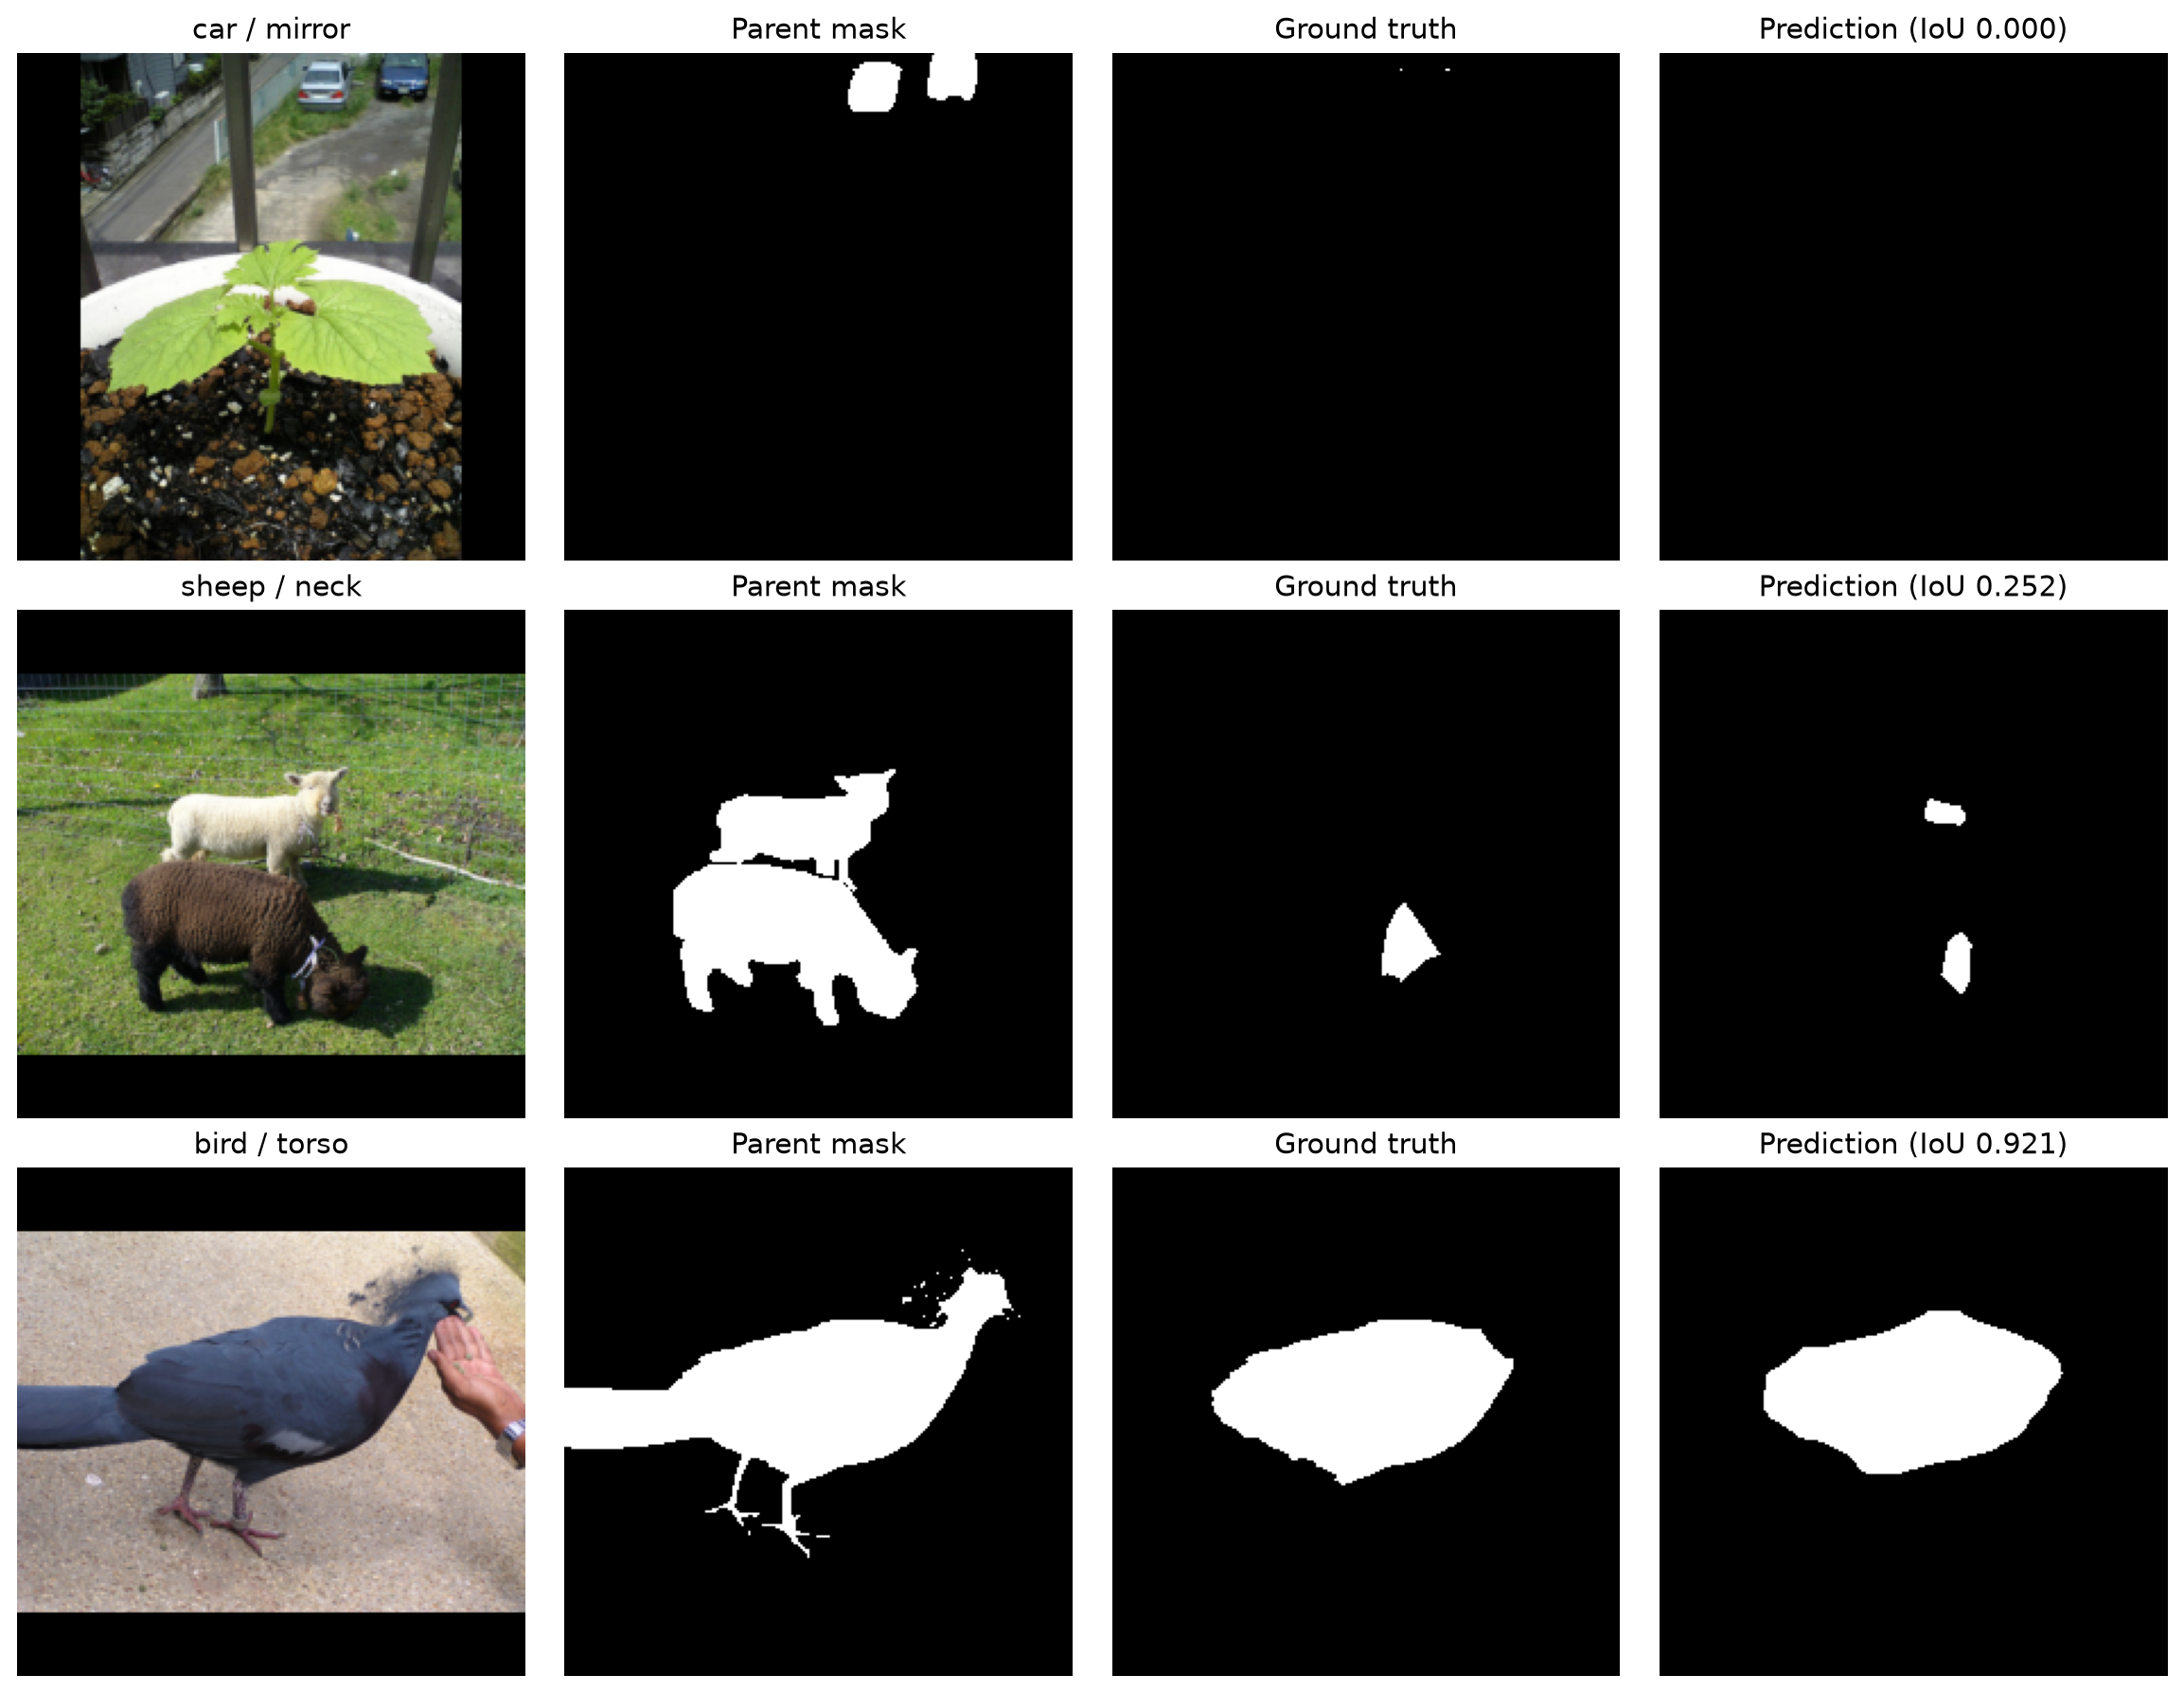

Saved experiment artifacts


,file,size_kb
0,baseline_comparison.csv,0.3
1,best.pt,4702.0
2,completion.json,0.3
3,config.json,1.3
4,detailed_predictions.csv,859.0
5,evaluation_comparison.png,40.6
6,history.csv,4.0
7,history.json,8.5
8,last.pt,4702.0
9,qualitative_unseen.png,1187.4


In [10]:
display(Image(filename=str(RESULT_DIR / "qualitative_unseen.png")))

print("Saved experiment artifacts")
artifact_rows = []
for path in sorted(RESULT_DIR.iterdir()):
    if path.is_file():
        artifact_rows.append({
            "file": path.name,
            "size_kb": round(path.stat().st_size / 1024, 1),
        })
display(pd.DataFrame(artifact_rows))


## 9. Interpretation guide

- **IoU and Dice:** higher values indicate better part-mask overlap.
- **Leakage:** lower values indicate fewer predicted pixels outside the parent object.
- **Seen versus unseen:** the gap summarizes generalization to held-out object classes.
- **Baseline delta:** positive values show improvement over the matched object-mask reference.
- **Geometry gates:** values summarize how strongly the trained model uses U, V, and D.

Saved outputs include `best.pt`, `last.pt`, `ui_model.pt`, complete histories,
detailed predictions, summary tables, per-query metrics, the standardized dashboard,
training/evaluation figures, configuration, and completion metadata.